In [5]:
import pandas as pd

df = pd.read_csv("tmdb_5000_movies.csv")
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [6]:
df = df[['title', 'overview', 'genres']]
df = df.dropna()

df.head()

,title,overview,genres
0,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""..."
2,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
3,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam..."
4,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."


In [7]:
import ast

def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return " ".join(L)

df['genres'] = df['genres'].apply(convert)

In [8]:
df['combined'] = df['overview'] + " " + df['genres']

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000, stop_words='english')
matrix = cv.fit_transform(df['combined'])

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(matrix)

In [11]:
def recommend(movie):
    movie = movie.lower()
    df['title_lower'] = df['title'].str.lower()
    
    idx = df[df['title_lower'] == movie].index[0]
    distances = similarity[idx]
    
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    for i in movies_list:
        print(df.iloc[i[0]].title)

In [12]:
recommend("Avatar")

Beowulf
The Helix... Loaded
Small Soldiers
Iron Man 3
Journey 2: The Mysterious Island


In [13]:
df['title_lower'] = df['title'].str.lower()

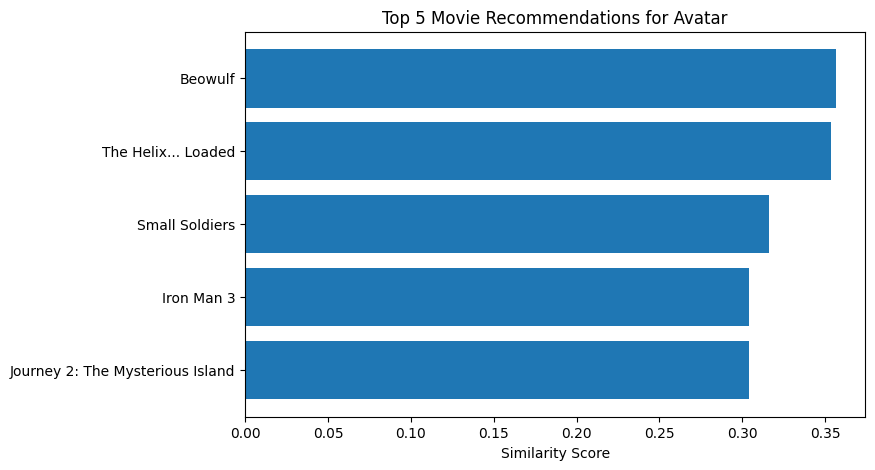

In [14]:
import matplotlib.pyplot as plt

movie = "Avatar"
movie = movie.lower()

idx = df[df['title_lower'] == movie].index[0]
distances = similarity[idx]

# get top 5
movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

names = [df.iloc[i[0]].title for i in movies_list]
scores = [i[1] for i in movies_list]

plt.figure(figsize=(8,5))
plt.barh(names, scores)
plt.xlabel("Similarity Score")
plt.title("Top 5 Movie Recommendations for Avatar")
plt.gca().invert_yaxis()
plt.show()

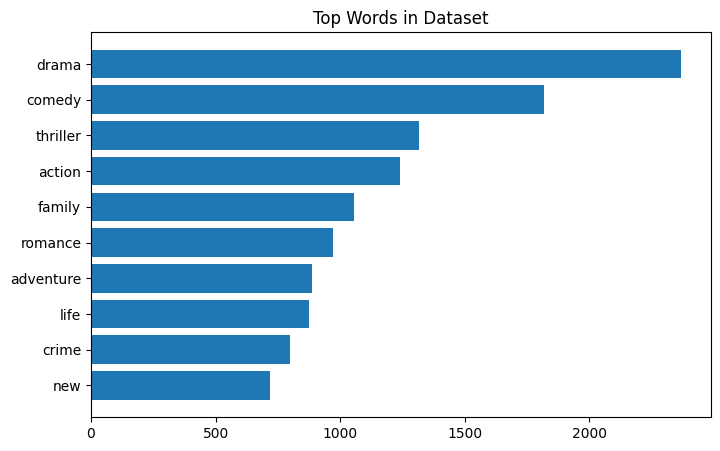

In [15]:
import numpy as np

words = cv.get_feature_names_out()
counts = np.asarray(matrix.sum(axis=0)).ravel()

top_words_idx = counts.argsort()[-10:]
top_words = words[top_words_idx]
top_counts = counts[top_words_idx]

plt.figure(figsize=(8,5))
plt.barh(top_words, top_counts)
plt.title("Top Words in Dataset")
plt.show()